# TLS-focused radial distance — visualization
Visualization of the within-TLS radial distance analysis. 

**Pinned Environment:** [`conda_envs/space2_20250604.yml`](../conda_envs/space2_20250604.yml)  

In [1]:
from pathlib import Path
import sys
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata
import scanpy as sc
import squidpy as sq

import pickle
import joblib

import matplotlib.colors as mcolors

import matplotlib as mpl
mpl.rcParams['axes.titlesize'] = 24
mpl.rcParams['pdf.fonttype'] = 42

warnings.simplefilter(action='ignore', category=Warning)

## Local file info

In [2]:
sys.path.append(str(Path.cwd().resolve().parents[0]))

from config.paths import BASE_OUTDIR, INPUTS_DIR, FUNCTIONS_DIR

inputs_dir = INPUTS_DIR
structures_dir = os.path.join(BASE_OUTDIR, "structures")
out_dir = os.path.join(BASE_OUTDIR, "downstream_analysis")

plot_out_dir = os.path.join(out_dir, 'plots')


In [3]:
import importlib
if str(FUNCTIONS_DIR) not in sys.path:
    sys.path.append(str(FUNCTIONS_DIR))

import plotting_utils as pu
import de_utils as du
from de_utils import filter_adata_expressed_in_n_cells

import distance_utils
importlib.reload(distance_utils)
from distance_utils import scvelo_heatmap


In [4]:
importlib.reload(du)

<module 'de_utils' from '/home/workspace/spatial_tls_manuscript/utils/de_utils.py'>

## Load adata
Loads the output of `02_distance_tls_bronchi.ipynb`.

In [5]:
adata = sc.read_h5ad(os.path.join(out_dir, 'adata_distance.h5ad'))

## Load palettes

In [6]:
with open(os.path.join(inputs_dir, 'palettes/20250519_celltype_palette_mapped.pkl'), 'rb') as f:
    celltype_palette_mapped = pickle.load(f)

with open(os.path.join(inputs_dir, 'palettes/20250520_celltype_palette_coarse_mapped.pkl'), 'rb') as f:
    celltype_palette_coarse_mapped = pickle.load(f)

with open(os.path.join(inputs_dir, 'palettes/20250520_celltype_palette_coarser_mapped.pkl'), 'rb') as f:
    celltype_palette_coarser_mapped = pickle.load(f)

with open(os.path.join(inputs_dir, 'palettes/20250521_zone_consol_palette_mapped.pkl'), 'rb') as f:
    zone_consol_palette_mapped = pickle.load(f)

In [7]:
import matplotlib.colors as clr
import colorcet

zissou = [
    "#3A9AB2",
    "#6FB2C1",
    "#91BAB6",
    "#A5C2A3",
    "#BDC881",
    "#DCCB4E",
    "#E3B710",
    "#E79805",
    "#EC7A05",
    "#EF5703",
    "#F11B00",
]

colormap = clr.LinearSegmentedColormap.from_list("Zissou", zissou)
colormap_r = clr.LinearSegmentedColormap.from_list("Zissou", zissou[::-1])

## Plot radial distances

In [8]:
# Palette for the TLS radial categories (computed in 02_distance_tls_bronchi.ipynb)
radial_category_palette = {'tls core': 'darkgreen',
                           'tls outer': 'palegreen',
                           'tls surround': 'darkkhaki'}

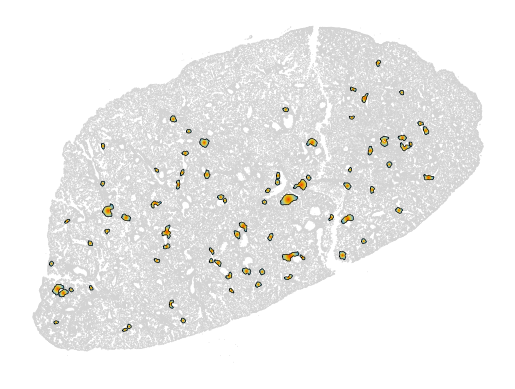

In [9]:
sample_label = 'HDM_day3'
    
# get sample subset of adata 
adata_sample = adata[adata.obs['sample_label'] == sample_label, :]
        
fig = sc.pl.embedding(adata_sample, basis='spatial', 
                color = 'tls_radial_dist_scaled',
                # color = 'tls_radial_dist_surr_scaled',
                      # color = 'tls_radial_dist_scaled_combined',
                      title='',
                cmap = colormap_r,
                      colorbar_loc=None,
                frameon=False, 
                size=1, 
                show=False, return_fig=True)

ax = plt.gca()
tls_poly = joblib.load(os.path.join(structures_dir, 'tls_poly_' + sample_label + '.pkl'))
for p in tls_poly.geoms:
        ax.plot(*p.exterior.xy, c='black', linewidth=0.5)

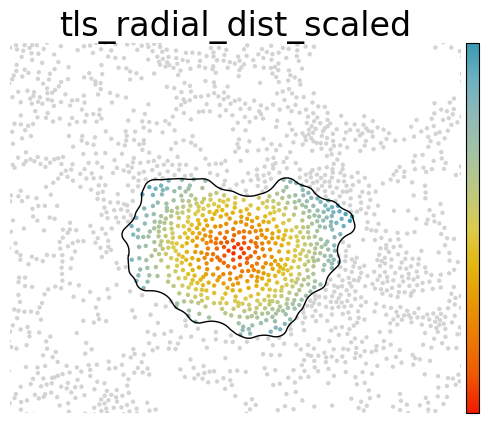

In [27]:
sample_label = 'HDM_day3'
    
# get sample subset of adata 
adata_sample = adata[adata.obs['sample_label'] == sample_label, :]
    
fig = sc.pl.embedding(adata_sample, basis='spatial', 
                color = 'tls_radial_dist_scaled',
                cmap = colormap_r,
                frameon=False, 
                size=40, 
                show=False, return_fig=True)

ax = plt.gca()
tls_poly = joblib.load(os.path.join(structures_dir, 'tls_poly_' + sample_label + '.pkl'))
for p in tls_poly.geoms:
        ax.plot(*p.exterior.xy, c='black', linewidth=1)

for ax in fig.axes:
    if ax.get_label() == '<colorbar>':  
        ax.set_yticks([])
        ax.set_yticklabels([])

# plt.xlim([2500, 6500])
# plt.ylim([2500, 6500])
plt.xlim([3800, 4200])
plt.ylim([4300, 4700])
plt.savefig(os.path.join(plot_out_dir, "tls_zoom_radial_tls_dist_colorbar.png"), dpi=300, bbox_inches='tight', transparent=True)


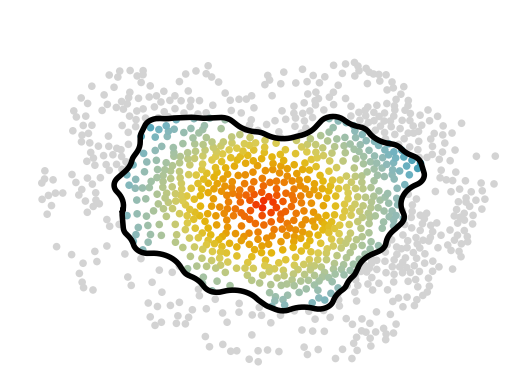

In [28]:
sample_label ='HDM_day3'
    
# get sample subset of adata 
adata_sample = adata[adata.obs['sample_label'] == sample_label, :]
adata_sample = adata_sample[~adata_sample.obs['tls_radial_category'].isna(), :]

fig = sc.pl.embedding(adata_sample, basis='spatial', 
                color = 'tls_radial_dist_scaled',
                # color = 'tls_radial_dist_surr_scaled',
                cmap = colormap_r,
                      title='',
                frameon=False, 
                size=120, 
                      colorbar_loc=None,
                show=False, return_fig=True)

ax = plt.gca()
tls_poly = joblib.load(os.path.join(structures_dir, 'tls_poly_' + sample_label + '.pkl'))
for p in tls_poly.geoms:
        ax.plot(*p.exterior.xy, c='black', linewidth=4)

# plt.xlim([2500, 6500])
# plt.ylim([2500, 6500])
plt.xlim([3830, 4160])
plt.ylim([4320, 4650])
plt.savefig(os.path.join(plot_out_dir, "tls_zoom_radial_tls_dist.png"), dpi=300, bbox_inches='tight', transparent=True)


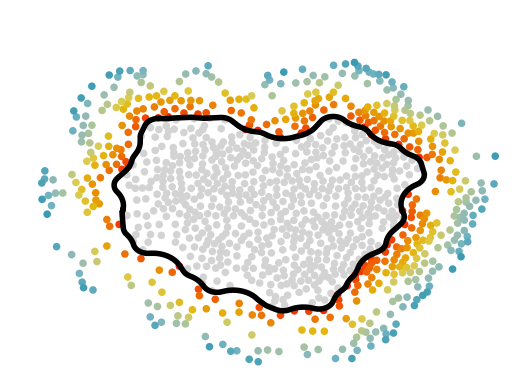

In [29]:
sample_label ='HDM_day3'
    
# get sample subset of adata 
adata_sample = adata[adata.obs['sample_label'] == sample_label, :]
adata_sample = adata_sample[~adata_sample.obs['tls_radial_category'].isna(), :]

fig = sc.pl.embedding(adata_sample, basis='spatial', 
                # color = 'tls_radial_dist_scaled',
                color = 'tls_radial_dist_surr_scaled',
                cmap = colormap_r,
                      title='',
                frameon=False, 
                size=120, 
                      colorbar_loc=None,
                show=False, return_fig=True)

ax = plt.gca()
tls_poly = joblib.load(os.path.join(structures_dir, 'tls_poly_' + sample_label + '.pkl'))
for p in tls_poly.geoms:
        ax.plot(*p.exterior.xy, c='black', linewidth=4)

# plt.xlim([2500, 6500])
# plt.ylim([2500, 6500])
plt.xlim([3830, 4160])
plt.ylim([4320, 4650])
plt.savefig(os.path.join(plot_out_dir, "tls_zoom_radial_surr_dist.png"), dpi=300, bbox_inches='tight', transparent=True)


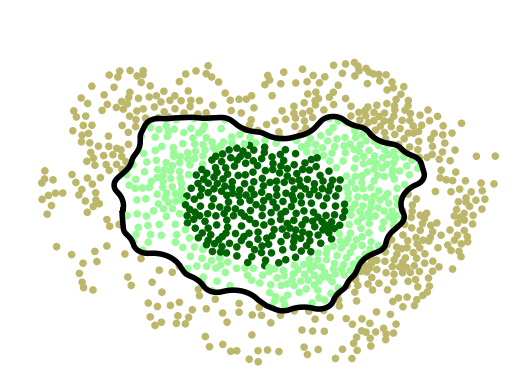

In [30]:
sample_label ='HDM_day3'
adata_sample = adata[adata.obs['sample_label'] == sample_label, :]
adata_sample = adata_sample[~adata_sample.obs['tls_radial_category'].isna(), :]

fig = sc.pl.embedding(adata_sample, basis='spatial', 
                color = 'tls_radial_category', 
                      palette = radial_category_palette,
                      title='',
                frameon=False, 
                size=120, 
                legend_loc = 'none',
                show=False, return_fig=True)

ax = plt.gca()
tls_poly = joblib.load(os.path.join(structures_dir, 'tls_poly_' + sample_label + '.pkl'))
for p in tls_poly.geoms:
        ax.plot(*p.exterior.xy, c='black', linewidth=4)

# plt.xlim([2500, 6500])
# plt.ylim([2500, 6500])
plt.xlim([3830, 4160])
plt.ylim([4320, 4650])
plt.savefig(os.path.join(plot_out_dir, "tls_zoom_radial_categories.png"), dpi=300, bbox_inches='tight', transparent=True)

## Plot cytokine/chemokine ligands by zone or tls radial category

In [31]:
df_lr = pd.read_csv(os.path.join(inputs_dir, 'interaction_input_CellChatDB.csv'))
ligands = df_lr['ligand'].tolist()
ligands_panel = list(set(ligands) & set(adata.var.index))
len(ligands_panel) 

99

In [32]:
ligands_highlight = ['Cd86', 'H2-DMb2', 'Cd80', 'Cxcl13', 'H2-Ab1', 
                     'Cd40lg', 'Icosl', 'Pdcd1lg2', 'Cd274', 
                     'Cxcl16', 'Il15', 'Il18', 'Il33', 'Icam1'    
]
genes_highlight_tls = ['Il21', 'Ccr7', 'Slamf6', 'Tcf7', 'Id3', 'Tbx21', 'Cxcr6', 'Il1rl1', 'Gata3', 'Il13', 'Calca',
                       'Cxcr5', 'Bcl6', 'Cd40lg', 'Il7r',
                      'Pdcd1', 'Nr4a1', 'Mki67',
                      'Klf2', 'Mt1', 'Prdm1']

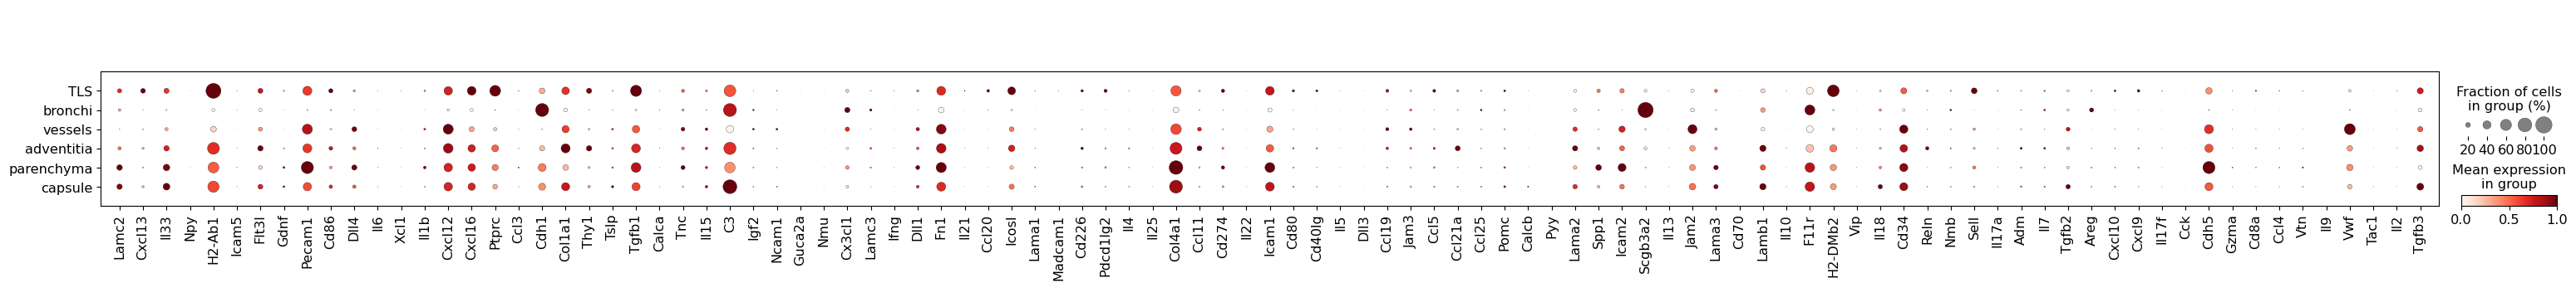

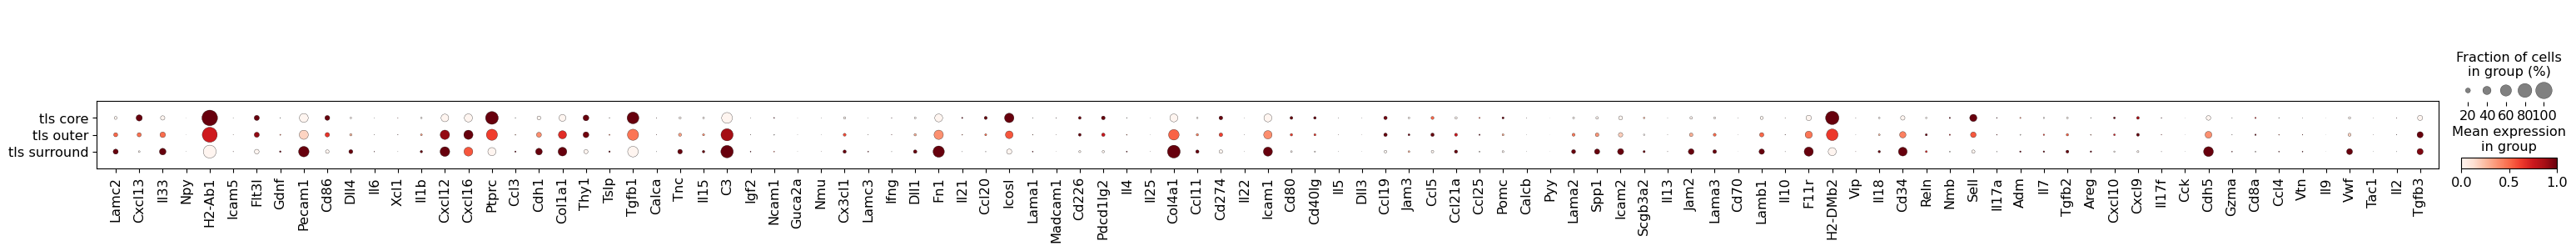

In [33]:
# all ligands
sc.pl.dotplot(adata, var_names = ligands_panel, groupby='zone_consol', standard_scale = 'var', swap_axes=False)
sc.pl.dotplot(adata, var_names = ligands_panel, groupby='tls_radial_category', standard_scale = 'var', swap_axes=False)

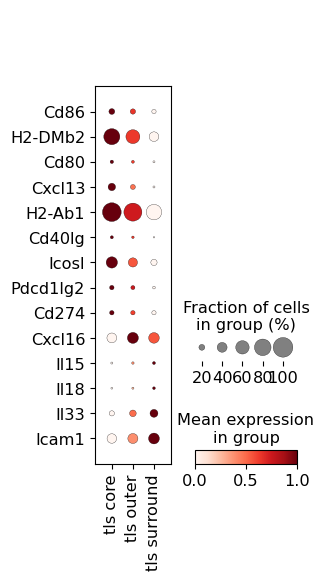

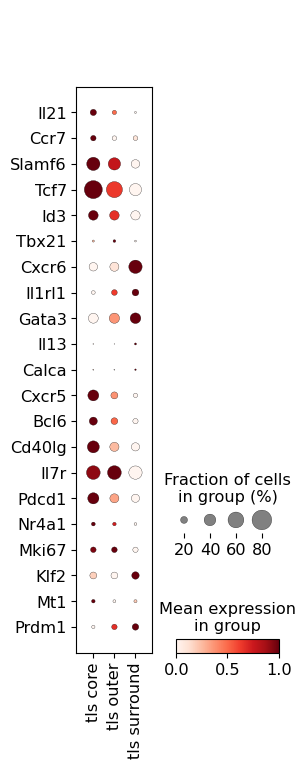

In [34]:
# highlight select 
sc.pl.dotplot(adata, var_names = ligands_highlight, groupby='tls_radial_category', standard_scale = 'var', swap_axes=True)
sc.pl.dotplot(adata[adata.obs['label_medium']=='CD4 act', :], var_names = genes_highlight_tls, groupby='tls_radial_category', standard_scale = 'var', swap_axes=True)

## Cell type composition in radial TLS categories

Text(0.5, 0, '')

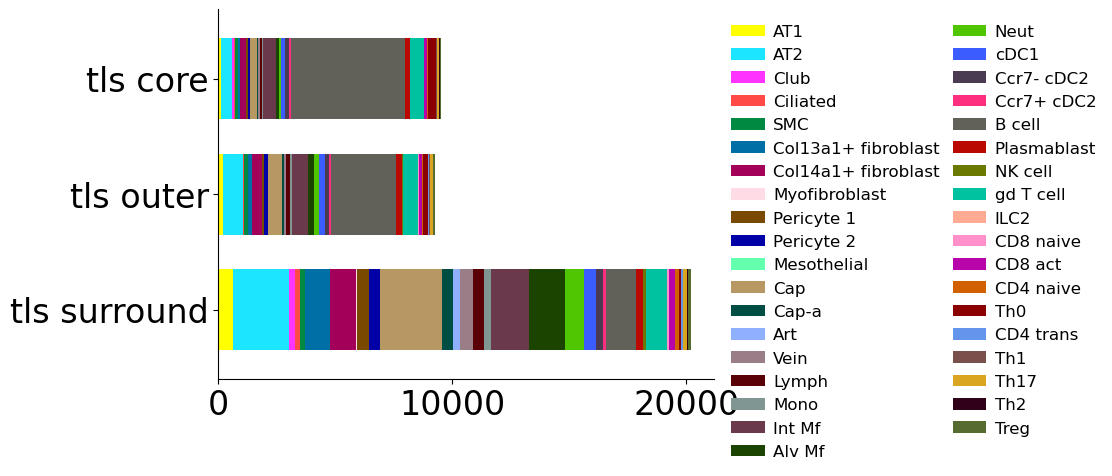

In [35]:
adata_d3 = adata[adata.obs['sample_label']=='HDM_day3', :]
adata_d3_cd4 = adata_d3[adata_d3.obs['label_medium']=='CD4 act', :]
    
zone_col = 'tls_radial_category'
label_col = 'label_fine'
    
ax1 = pu.zone_composition(adata_d3, label_col, zone_col,
                            remove_unlabeled = True, 
                       palette_map = celltype_palette_mapped,
                       plot_counts = True, 
                       zone_ncell_filter = False,
                       horizontal=True
                      )
ax1.tick_params(axis='x', labelsize=24)
ax1.tick_params(axis='y', labelsize=24)
ax1.set_title('')       
ax1.set_xlabel('')   

## Plotting along radial TLS distance

In [36]:
genes_highlight_tls = ['Il21', 'Ccr7', 'Slamf6', 'Tcf7', 'Id3', 'Tbx21', 'Cxcr6', 'Il1rl1', 'Gata3', 'Il13', 'Calca',
                       'Irf4',
                       'Cxcr5', 'Bcl6', 'Cd40lg', 'Il7r',
                      'Pdcd1', 'Tigit', 'Nr4a1', 'Mki67',
                      'Klf2', 'Mt1', 'Prdm1']

In [37]:
# CITE genes expressed in 5% of at least one subset
gene_df = pd.read_csv(os.path.join(BASE_OUTDIR, 'cell_labeling/ouputs_mouselung_hurskainen_ref_consolidate_labels_xenseg_HDM/cite_integration/cite_expressed_genes_by_annotation.csv'))
genes_cite_filt = gene_df['x'].tolist()

# Xenium genes expressed in 5% of at least one subset
genes_xen_filt = []
adata_cd4 = adata.copy()
for subset in adata_cd4.obs['label_fine'].unique().tolist():
    adata_cd4_subset = adata_cd4[adata_cd4.obs['label_fine'] == subset, :]
    adata_cd4_subset = filter_adata_expressed_in_n_cells(adata_cd4_subset, fraction=0.05)
    genes_xen_filt.extend(adata_cd4_subset.var.index.tolist())
genes_xen_filt = list(set(genes_xen_filt))

# take the intersection 
genes_cite_xen_filt = list(set(genes_cite_filt) & set(genes_xen_filt))

HDM_day3
Creating Heatmap for sample labels  HDM_day3
Subset to 'label_medium'=='CD4 act'
removing genes by expression threshold:  0.05  fraction
adata shape:  (1610, 164)
Setting `n_convolve` to 322 (5 bins, 1610 cells) 


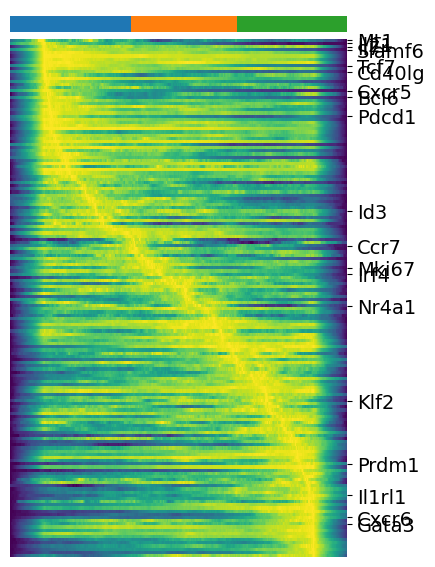

In [38]:
sample_label = 'HDM_day3'
print(sample_label)
adata_plot = adata[adata.obs['sample_label']==sample_label, :]
adata_plot = adata_plot[~adata_plot.obs['tls_radial_dist_scaled_combined'].isna(), :]
s = scvelo_heatmap(
    adata_plot[:,genes_cite_xen_filt],
    sample_label=[sample_label],
    sortby = 'tls_radial_dist_scaled_combined',
    key_name = 'label_medium',
    key_value = 'CD4 act',
    col_color = 'tls_radial_category',
    palette = radial_category_palette,
    highlight = genes_highlight_tls,
    expression_threshold= 0.05, # filter in addition to genes cite filter (since now analyze just the tls associated subset)
    figsize=(5,6)
    # figsize=(5,16)
)
s
plt.savefig(os.path.join(plot_out_dir, f"{sample_label}_scVelo_tls_radial_dist_scaled_combined_CD4.pdf"), dpi=300, bbox_inches='tight', transparent=True)
plt.savefig(os.path.join(plot_out_dir, f"{sample_label}_scVelo_tls_radial_dist_scaled_combined_CD4_showallgenes.pdf"), dpi=300, bbox_inches='tight', transparent=True)


HDM_day3
Creating Heatmap for sample labels  HDM_day3
Subset to 'label_medium'=='CD4 act'
removing genes by expression threshold:  0.05  fraction
adata shape:  (1610, 164)
Setting `n_convolve` to 322 (5 bins, 1610 cells) 


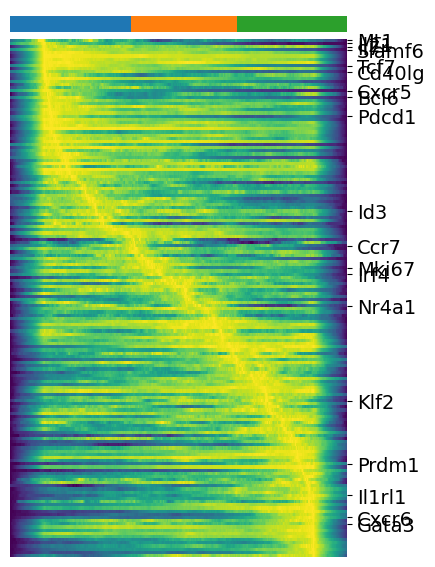

In [39]:
sample_label = 'HDM_day3'
print(sample_label)
adata_plot = adata[adata.obs['sample_label']==sample_label, :]
adata_plot = adata_plot[~adata_plot.obs['tls_radial_dist_scaled_combined'].isna(), :]
s = scvelo_heatmap(
    adata_plot[:,genes_cite_xen_filt],
    sample_label=[sample_label],
    sortby = 'tls_radial_dist_scaled_combined',
    key_name = 'label_medium',
    key_value = 'CD4 act',
    col_color = 'tls_radial_category',
    palette = radial_category_palette,
    highlight = genes_highlight_tls,
    expression_threshold= 0.05, # filter in addition to genes cite filter (since now analyze just the tls associated subset)
    figsize=(5,6)
    # figsize=(5,16)
)
s
plt.savefig(os.path.join(plot_out_dir, f"{sample_label}_scVelo_tls_radial_dist_scaled_combined_CD4.pdf"), dpi=300, bbox_inches='tight', transparent=True)
plt.savefig(os.path.join(plot_out_dir, f"{sample_label}_scVelo_tls_radial_dist_scaled_combined_CD4_showallgenes.pdf"), dpi=300, bbox_inches='tight', transparent=True)


## ligands

In [40]:
df_lr = pd.read_csv(os.path.join(inputs_dir, 'interaction_input_CellChatDB.csv'))

ligands = df_lr['ligand'].tolist()

ligands_panel = list(set(ligands) & set(adata.var.index))
len(ligands_panel)

99

In [41]:
ligands_highlight = ['Cd86', 'H2-DMb2', 'Cd80', 'Cxcl13', 'H2-Ab1', 
                     'Cd40lg', 'Icosl', 'Pdcd1lg2', 'Cd274', 
                     'Cxcl16', 'Il15', 'Il18', 'Il33', 'Icam1'    
]

HDM_day3
Creating Heatmap for sample labels  HDM_day3
using all cells
removing genes by expression threshold:  0.05  fraction
adata shape:  (38988, 54)
Setting `n_convolve` to 7797 (5 bins, 38988 cells) 


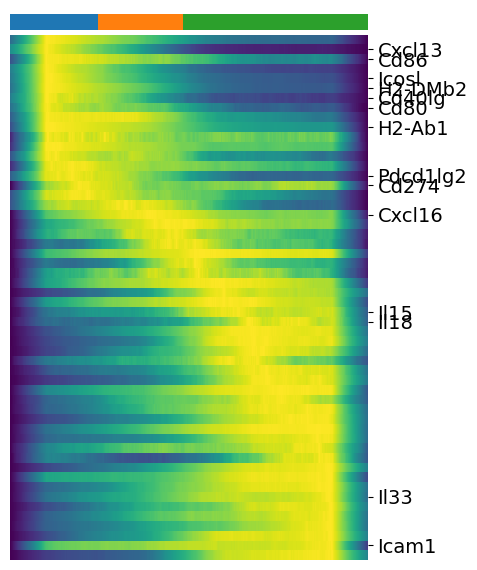

In [42]:
sample_label = 'HDM_day3'
print(sample_label)
adata_plot = adata[adata.obs['sample_label']==sample_label, :]
adata_plot = adata_plot[~adata_plot.obs['tls_radial_dist_scaled_combined'].isna(), :]
s = scvelo_heatmap(
    adata_plot[:,ligands_panel],
    sample_label=[sample_label],
    sortby = 'tls_radial_dist_scaled_combined',
    key_name = 'label_medium',
    col_color = 'tls_radial_category',
    palette = radial_category_palette,
    key_value = None,
    highlight = ligands_highlight,
    expression_threshold= 0.05,
    figsize=(5,6)
)
s
plt.savefig(os.path.join(plot_out_dir, f"{sample_label}_scVelo_tls_radial_dist_scaled_combined_allcells_ligands.pdf"), dpi=300, bbox_inches='tight', transparent=True)


HDM_day3
Creating Heatmap for sample labels  HDM_day3
using all cells
removing genes by expression threshold:  0.05  fraction
adata shape:  (38988, 54)
Setting `n_convolve` to 7797 (5 bins, 38988 cells) 


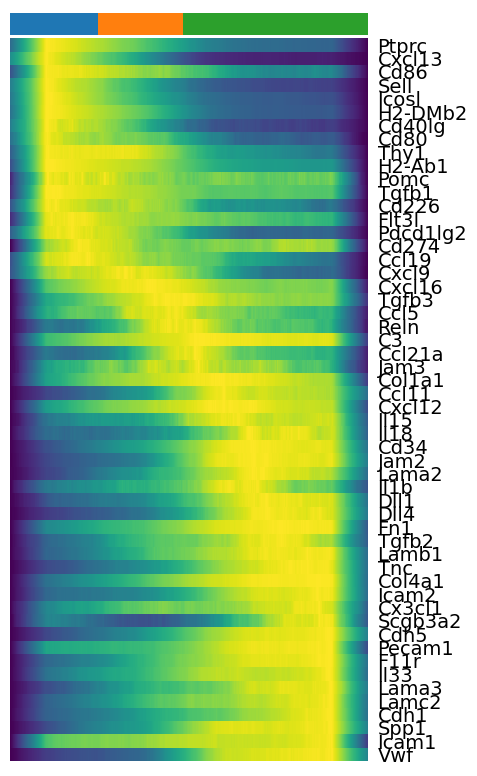

In [43]:
sample_label = 'HDM_day3'
print(sample_label)
adata_plot = adata[adata.obs['sample_label']==sample_label, :]
adata_plot = adata_plot[~adata_plot.obs['tls_radial_dist_scaled_combined'].isna(), :]
s = scvelo_heatmap(
    adata_plot[:,ligands_panel],
    sample_label=[sample_label],
    sortby = 'tls_radial_dist_scaled_combined',
    key_name = 'label_medium',
    col_color = 'tls_radial_category',
    palette = radial_category_palette,
    key_value = None,
    highlight = None,
    expression_threshold= 0.05,
    figsize=(5,8)
)
s
plt.savefig(os.path.join(plot_out_dir, f"{sample_label}_scVelo_tls_radial_dist_scaled_combined_allcells_ligands_showallgenes.pdf"), dpi=300, bbox_inches='tight', transparent=True)


## Session info

In [44]:
import session_info
print('active conda environment: ', os.path.basename(sys.prefix))
session_info.show()

active conda environment:  space2
